# Setup

In [1]:
import json
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import tensorflow as tf
from geexhp import datavis

datavis.configure_matplotlib()

2026-02-24 09:22:01.169588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 09:22:01.190363: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 09:22:01.322073: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 09:22:01.435006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771935721.546847    7203 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771935721.57

In [2]:
TELESCOPE = {
    "LUVOIR": dict(prefix="B", region_bins={"UV": 8, "Vis": 94, "NIR": 49}),
    "HABEX": dict(prefix="SS", region_bins={"UV": 7, "Vis": 109, "NIR": 25}),
}

In [3]:
def parse_example(
    example_proto,
    input_stats,
    output_stats,
    telescope="LUVOIR",
):

    meta = TELESCOPE[telescope]
    pfx = meta["prefix"]
    bins = meta["region_bins"]

    # 1) Define raw feature schemas.
    raw_input_features = {
        f"NOISY_ALBEDO_{pfx}-{r}": tf.io.VarLenFeature(tf.float32)
        for r in ["NIR", "UV", "Vis"]
    }

    raw_output_features = {
        # Planetary parameters.
        "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
        "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
        # Chemical abundances.
        "CH4": tf.io.FixedLenFeature([], tf.float32),
        "CO2": tf.io.FixedLenFeature([], tf.float32),
        "H2O": tf.io.FixedLenFeature([], tf.float32),
        "N2": tf.io.FixedLenFeature([], tf.float32),
        "O2": tf.io.FixedLenFeature([], tf.float32),
        "O3": tf.io.FixedLenFeature([], tf.float32),
        "Earth_type": tf.io.FixedLenFeature([], tf.string),
        "OBJECT-STAR-TYPE": tf.io.FixedLenFeature([], tf.string),
        "GEOMETRY-OBS-ALTITUDE": tf.io.FixedLenFeature([], tf.float32),
    }

    clean_albedo_features = {
        f"ALBEDO_{pfx}-{r}": tf.io.VarLenFeature(tf.float32)
        for r in ["NIR", "UV", "Vis"]
    }

    # 2) Parse the example.
    all_features = {
        **raw_input_features,
        **clean_albedo_features,
        **raw_output_features,
    }
    parsed = tf.io.parse_single_example(example_proto, all_features)

    # 3) Normalize input spectra.
    normalized_inputs = {}
    for region in ["UV", "Vis", "NIR"]:
        spectrum = parsed[f"NOISY_ALBEDO_{pfx}-{region}"]
        if isinstance(spectrum, tf.SparseTensor):
            spectrum = tf.sparse.to_dense(spectrum, default_value=0.0)

        mean = input_stats[region][0]
        std = input_stats[region][1]
        normalized = (spectrum - mean) / std

        normalized = tf.reshape(normalized, [bins[region], 1])
        normalized_inputs[f"NOISY_ALBEDO_{pfx}-{region}"] = normalized

    # Just to visualize in the same units
    clean_inputs = {}
    for region in ["UV", "Vis", "NIR"]:
        spectrum_clean = parsed[f"ALBEDO_{pfx}-{region}"]
        if isinstance(spectrum_clean, tf.SparseTensor):
            spectrum_clean = tf.sparse.to_dense(spectrum_clean, default_value=0.0)

        # mean = input_stats[region][0]
        # std  = input_stats[region][1]
        # normalized = (spectrum_clean - mean) / std

        spectrum_clean = tf.reshape(spectrum_clean, [bins[region], 1])
        clean_inputs[f"ALBEDO_{pfx}-{region}"] = spectrum_clean

    physical_outputs = []
    main_chemical_outputs = []
    other_chemical_outputs = []

    for param in [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]:
        val = parsed[param]
        # To avoid a very ponctual error we found
        # the floating point precision error generates a single NaN value here :(
        if val == 273.15:
            val += 0.00002
        min_ = output_stats["physical_output_stats"][param][0]
        max_ = output_stats["physical_output_stats"][param][1]
        best_n = output_stats["physical_output_stats"][param][2]
        processed = (val - min_) / (max_ - min_)
        processed = tf.math.pow(float(processed), float(1 / best_n))
        physical_outputs.append(processed)

    for chem in ["O2", "O3"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(float(val), float(1 / best_n))
        main_chemical_outputs.append(processed)

    for chem in ["CH4", "CO2", "H2O", "N2"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(float(val), float(1 / best_n))
        other_chemical_outputs.append(processed)

    grouped_outputs = {
        "physical_output": physical_outputs,
        "main_chemical_output": main_chemical_outputs,
        "other_chemical_output": other_chemical_outputs,
        "earth_type": parsed["Earth_type"],
        "star_type": parsed["OBJECT-STAR-TYPE"],
        "obs_altitude": parsed["GEOMETRY-OBS-ALTITUDE"],
    }

    return normalized_inputs, grouped_outputs, clean_inputs


def read_tfrecord(
    file_path,
    telescope="LUVOIR",
    batch_size=1024,
    shuffle_buffer=None,
    repeat=False,
):

    meta = TELESCOPE[telescope]
    pfx = meta["prefix"]

    with open("../data/normalization_stats.json") as f:
        stats = json.load(f)

    # Create lookup dictionaries for input normalization statistics.
    input_stats = {
        r: (stats["inputs"][f"{pfx}-{r}"]["mean"], stats["inputs"][f"{pfx}-{r}"]["std"])
        for r in ["UV", "Vis", "NIR"]
    }

    physical_keys = [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]
    physical_output_stats = {
        key: (
            stats["outputs"][key]["min"],
            stats["outputs"][key]["max"],
            stats["outputs"][key]["best_n"],
        )
        for key in physical_keys
    }

    chemical_keys = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]
    chemical_output_stats = {key: stats["outputs"][key] for key in chemical_keys}

    output_stats = {
        "physical_output_stats": physical_output_stats,
        "chemical_output_stats": chemical_output_stats,
    }

    dataset = tf.data.TFRecordDataset(file_path, num_parallel_reads=tf.data.AUTOTUNE)

    if shuffle_buffer is not None and shuffle_buffer > 0:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Parse the dataset using the parse_example function.
    parsed_dataset = dataset.map(
        lambda x: parse_example(x, input_stats, output_stats, telescope=telescope),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if repeat:
        parsed_dataset = parsed_dataset.repeat()

    parsed_dataset = parsed_dataset.batch(batch_size, drop_remainder=False)
    parsed_dataset = parsed_dataset.prefetch(tf.data.AUTOTUNE)

    return parsed_dataset

In [4]:
luvoir_ds = read_tfrecord("../data/test.tfrecord", telescope="LUVOIR", batch_size=1)
habex_ds = read_tfrecord("../data/test.tfrecord", telescope="HABEX", batch_size=1)

2026-02-24 09:22:06.849216: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
model_LUVOIR = tf.keras.models.load_model("../models/luvoir_model.keras")
model_HABEX = tf.keras.models.load_model("../models/habex_model.keras")

# Integrated Gradients

https://www.tensorflow.org/tutorials/interpretability/integrated_gradients?hl=pt-br

Given a model $f$ and an input sample $x$, we aim to quantify **how much each spectral bin $x_i$ contributed to the prediction** of a target output.

The simple gradient $\partial f / \partial x_i$ is often unstable, as it depends on the exact evaluation point and can vanish in saturated ReLU regions.

**Integrated Gradients** addresses this limitation by integrating the gradient along a linear path between a **baseline** $x'$ (a null spectrum containing no information) and the actual sample $x$:

$$
\text{IG}_i(x) = (x_i - x'_i) \cdot \int_{\alpha=0}^{1}
\frac{\partial f\big(x' + \alpha(x - x')\big)}{\partial x_i} , d\alpha
$$

In practice, the integral is approximated using a Riemann sum with a fixed number of `steps`, corresponding to uniformly spaced values of $\alpha \in [0,1]$.

Rather than running the IG loop one sample at a time, we process a full batch simultaneously. The key identity that makes this valid is the linearity of differentiation:

$$
\nabla_x \sum_{i=1}^{B} f(x_i) = \sum_{i=1}^{B} \nabla_x f(x_i)
$$

Summing the model outputs before differentiating is mathematically equivalent to computing individual gradients and summing them afterwards, while being significantly faster because it keeps the GPU fully utilised. The Riemann approximation of the path integral becomes:

$$
\overline{\nabla f} \approx \frac{1}{S} \sum_{s=1}^{S}
    \nabla_x f\!\left(x' + \frac{s}{S}(x - x')\right)
$$

where $x'$ is the baseline (a zero spectrum - no spectral information), $x$ is the real noisy spectrum, and $S$ is the number of interpolation steps (`steps=24` here).  The final IG value for a bin $i$ in a batch of $B$ samples is:

$$
\mathrm{IG}_i(x) = (x_i - x'_i) \cdot \overline{\nabla f}_i
$$

To avoid GPU out-of-memory errors the batch is split into chunks of 64 samples. The IG curves are accumulated and averaged at the end.

For each geological era and each target gas we collect the IG curve of every sample and compute the **mean IG** (with sign preserved):

$$
\mu_{\lambda}^{\,\mathrm{gas, era}} =
    \frac{1}{N_{\mathrm{era}}} \sum_{i=1}^{N_{\mathrm{era}}} \mathrm{IG}_{\lambda}^{(i)}
$$

- **Positive values** (green): that wavelength bin pushes the predicted abundance *upward*.
- **Negative values** (red): that bin pushes the prediction *downward*.
- **Near zero** (yellow): that bin carries little information for this gas in this era.

Wavelength bin widths are **not uniform**: UV bins span ~30–55 nm each, while Vis bins span ~3.6 nm. The horizontal extent of each pixel in the heatmap is proportional to the true spectral width of the bin.The HabEx/SS detector does not cover beyond ~1.76 µm; the region 1.76–2.0 µm is shown in white (zero) to indicate no data. The colour scale is normalised independently for LUVOIR-B and HabEx/SS using the 99th percentile of |IG| across all eras, so that a small number of high-attribution bins do not saturate the entire map Vertical dashed lines mark the UV/Vis and Vis/NIR spectral boundaries.

In [6]:
uv_b = np.array(
    [
        0.2,
        0.22857143,
        0.26122449,
        0.29854227,
        0.34119117,
        0.38993277,
        0.44563745,
        0.50929994,
    ]
)
vis_b = np.array(
    [
        0.515,
        0.51867857,
        0.52238342,
        0.52611473,
        0.52987269,
        0.5336575,
        0.53746934,
        0.5413084,
        0.54517489,
        0.549069,
        0.55299092,
        0.55694085,
        0.560919,
        0.56492557,
        0.56896075,
        0.57302475,
        0.57711779,
        0.58124006,
        0.58539177,
        0.58957314,
        0.59378438,
        0.5980257,
        0.60229731,
        0.60659943,
        0.61093229,
        0.61529609,
        0.61969106,
        0.62411742,
        0.62857541,
        0.63306523,
        0.63758712,
        0.64214132,
        0.64672804,
        0.65134753,
        0.65600001,
        0.66068572,
        0.66540491,
        0.6701578,
        0.67494464,
        0.67976568,
        0.68462114,
        0.6895113,
        0.69443638,
        0.69939664,
        0.70439233,
        0.7094237,
        0.71449101,
        0.71959452,
        0.72473448,
        0.72991116,
        0.73512481,
        0.7403757,
        0.7456641,
        0.75099027,
        0.75635448,
        0.76175702,
        0.76719814,
        0.77267812,
        0.77819725,
        0.78375581,
        0.78935406,
        0.7949923,
        0.80067082,
        0.8063899,
        0.81214983,
        0.8179509,
        0.8237934,
        0.82967764,
        0.83560391,
        0.84157251,
        0.84758374,
        0.85363791,
        0.85973532,
        0.86587629,
        0.87206112,
        0.87829013,
        0.88456363,
        0.89088194,
        0.89724539,
        0.90365428,
        0.91010895,
        0.91660973,
        0.92315694,
        0.92975092,
        0.936392,
        0.94308052,
        0.9498168,
        0.95660121,
        0.96343408,
        0.97031575,
        0.97724657,
        0.98422691,
        0.9912571,
        0.99833751,
    ]
)
nir_b = np.array(
    [
        1.01,
        1.02442857,
        1.03906327,
        1.05390703,
        1.06896284,
        1.08423374,
        1.09972279,
        1.11543312,
        1.13136788,
        1.14753028,
        1.16392356,
        1.18055104,
        1.19741606,
        1.214522,
        1.23187232,
        1.24947049,
        1.26732007,
        1.28542464,
        1.30378785,
        1.32241339,
        1.34130501,
        1.36046651,
        1.37990175,
        1.39961463,
        1.41960913,
        1.43988926,
        1.4604591,
        1.48132281,
        1.50248456,
        1.52394862,
        1.54571932,
        1.56780102,
        1.59019818,
        1.6129153,
        1.63595694,
        1.65932776,
        1.68303244,
        1.70707576,
        1.73146256,
        1.75619774,
        1.78128628,
        1.80673322,
        1.8325437,
        1.85872289,
        1.88527608,
        1.91220859,
        1.93952586,
        1.96723337,
        1.9953367,
    ]
)

uv_ss = np.array(
    [0.2, 0.22857143, 0.26122449, 0.29854227, 0.34119117, 0.38993277, 0.44563745]
)
vis_ss = np.array(
    [
        0.45,
        0.45321429,
        0.45645153,
        0.4597119,
        0.46299556,
        0.46630267,
        0.4696334,
        0.47298792,
        0.47636641,
        0.47976903,
        0.48319595,
        0.48664735,
        0.4901234,
        0.49362428,
        0.49715017,
        0.50070124,
        0.50427768,
        0.50787966,
        0.51150737,
        0.515161,
        0.51884072,
        0.52254673,
        0.5262792,
        0.53003834,
        0.53382433,
        0.53763736,
        0.54147762,
        0.54534532,
        0.54924065,
        0.55316379,
        0.55711496,
        0.56109436,
        0.56510217,
        0.56913862,
        0.57320389,
        0.57729821,
        0.58142176,
        0.58557478,
        0.58975745,
        0.59397001,
        0.59821265,
        0.6024856,
        0.60678907,
        0.61112327,
        0.61548844,
        0.61988479,
        0.62431253,
        0.62877191,
        0.63326314,
        0.63778645,
        0.64234206,
        0.64693022,
        0.65155115,
        0.65620509,
        0.66089227,
        0.66561293,
        0.6703673,
        0.67515564,
        0.67997818,
        0.68483517,
        0.68972685,
        0.69465347,
        0.69961528,
        0.70461253,
        0.70964548,
        0.71471438,
        0.71981948,
        0.72496105,
        0.73013934,
        0.73535462,
        0.74060715,
        0.7458972,
        0.75122504,
        0.75659093,
        0.76199516,
        0.76743798,
        0.77291968,
        0.77844053,
        0.78400082,
        0.78960083,
        0.79524083,
        0.80092113,
        0.80664199,
        0.81240372,
        0.8182066,
        0.82405094,
        0.82993701,
        0.83586514,
        0.8418356,
        0.84784871,
        0.85390477,
        0.86000409,
        0.86614698,
        0.87233374,
        0.8785647,
        0.88484016,
        0.89116045,
        0.89752588,
        0.90393678,
        0.91039347,
        0.91689628,
        0.92344554,
        0.93004158,
        0.93668473,
        0.94337534,
        0.95011373,
        0.95690026,
        0.96373526,
        0.97061909,
    ]
)
nir_ss = np.array(
    [
        0.975,
        0.999375,
        1.02435937,
        1.04996836,
        1.07621757,
        1.10312301,
        1.13070108,
        1.15896861,
        1.18794282,
        1.2176414,
        1.24808243,
        1.27928449,
        1.3112666,
        1.34404827,
        1.37764947,
        1.41209071,
        1.44739298,
        1.4835778,
        1.52066725,
        1.55868393,
        1.59765103,
        1.63759231,
        1.67853211,
        1.72049542,
        1.7635078,
    ]
)

In [7]:
def group_by_era(ds):
    buckets = {}
    for sample in ds:  # sample = (inputs, outputs, clean)
        era = sample[1]["earth_type"][0].numpy().decode().lower()
        buckets.setdefault(era, []).append(sample)
    return buckets

In [8]:
gas_targets = {
    "O2": ("main_chemical_output", 0),
    "O3": ("main_chemical_output", 1),
    "CH4": ("other_chemical_output", 0),
    "CO2": ("other_chemical_output", 1),
    "H2O": ("other_chemical_output", 2),
    "N2": ("other_chemical_output", 3),
}

bands_B = ["NOISY_ALBEDO_B-UV", "NOISY_ALBEDO_B-Vis", "NOISY_ALBEDO_B-NIR"]
bands_SS = ["NOISY_ALBEDO_SS-UV", "NOISY_ALBEDO_SS-Vis", "NOISY_ALBEDO_SS-NIR"]
wave_B = np.concatenate([uv_b, vis_b, nir_b])
wave_SS = np.concatenate([uv_ss, vis_ss, nir_ss])

In [9]:
b_L = group_by_era(luvoir_ds)
b_H = group_by_era(habex_ds)

eras = ["modern", "proterozoic", "archean"]
rng = random.Random(0)

pairs = {}
for era in eras:
    n = min(len(b_L[era]), len(b_H[era]))
    idx = rng.randrange(n)
    pairs[era] = (b_L[era][idx], b_H[era][idx])

2026-02-24 09:22:09.441013: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-24 09:22:16.853190: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-24 09:22:28.937810: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
baseline_B = {k: tf.zeros_like(v) for k, v in pairs["modern"][0][0].items()}
baseline_SS = {k: tf.zeros_like(v) for k, v in pairs["modern"][1][0].items()}

In [11]:
def integrated_gradients_batch(
    model,
    input_dict,
    baseline_dict,
    target_group="main_chemical_output",
    target_index=1,
    steps=24,
):
    inputs = {k: tf.cast(v, tf.float32) for k, v in input_dict.items()}
    baselines = {k: tf.cast(v, tf.float32) for k, v in baseline_dict.items()}

    alphas = tf.linspace(1.0 / float(steps), 1.0, steps)
    grads_sum = {k: tf.zeros_like(v, dtype=tf.float32) for k, v in inputs.items()}

    for alpha in alphas:
        interpolated_input = {
            k: baselines[k] + alpha * (inputs[k] - baselines[k]) for k in inputs
        }

        with tf.GradientTape() as tape:
            for tensor in interpolated_input.values():
                tape.watch(tensor)

            preds = model(interpolated_input, training=False)
            output = tf.reduce_sum(preds[target_group][:, target_index])

        grad = tape.gradient(output, interpolated_input)
        grads_sum = {k: grads_sum[k] + grad[k] for k in grads_sum}

    avg_grads = {k: grads_sum[k] / tf.cast(steps, tf.float32) for k in grads_sum}

    ig_dict = {k: (inputs[k] - baselines[k]) * avg_grads[k] for k in inputs}
    return ig_dict


def stack_inputs(samples, feature_keys):
    return {
        k: tf.concat([sample[0][k] for sample in samples], axis=0) for k in feature_keys
    }


def aggregate_ig_heatmap_by_era(
    model,
    buckets,
    baseline_dict,
    bands,
    gas_targets,
    eras,
    steps=24,
    chunk_size=64,
    max_samples_per_era=None,
):
    feature_keys = list(baseline_dict.keys())
    era_maps = {}
    era_counts = {}
    rng = random.Random(0)

    for era in eras:
        samples = list(buckets[era])
        if max_samples_per_era is not None and len(samples) > max_samples_per_era:
            idx = rng.sample(range(len(samples)), k=max_samples_per_era)
            samples = [samples[i] for i in idx]

        era_counts[era] = len(samples)
        gas_rows = []

        for _, (group, target_idx) in tqdm(
            gas_targets.items(),
            total=len(gas_targets),
            desc=f"{era} | {model.name}",
            leave=False,
        ):
            curve_sum = None
            total = 0

            for start in range(0, len(samples), chunk_size):
                chunk = samples[start : start + chunk_size]
                batch_inputs = stack_inputs(chunk, feature_keys)

                ig_batch = integrated_gradients_batch(
                    model=model,
                    input_dict=batch_inputs,
                    baseline_dict=baseline_dict,
                    target_group=group,
                    target_index=target_idx,
                    steps=steps,
                )

                curves = np.concatenate(
                    [tf.squeeze(ig_batch[b], axis=-1).numpy() for b in bands],
                    axis=1,
                )
                curves = curves

                if curve_sum is None:
                    curve_sum = np.zeros(curves.shape[1], dtype=np.float64)

                curve_sum += curves.sum(axis=0)
                total += curves.shape[0]

            gas_rows.append((curve_sum / max(total, 1)).astype(np.float32))

        era_maps[era] = np.stack(gas_rows, axis=0)

    return era_maps, era_counts

In [12]:
eras_heatmap = ["modern", "proterozoic", "archean"]
gas_order_heatmap = list(gas_targets.keys())

max_samples_per_era = 5_000  # None = entire test sample per era
ig_steps_heatmap = 24
chunk_size_heatmap = 64

baseline_B_heatmap = {k: tf.identity(v) for k, v in baseline_B.items()}
baseline_SS_heatmap = {k: tf.identity(v) for k, v in baseline_SS.items()}

ig_heatmap_L, n_samples_L = aggregate_ig_heatmap_by_era(
    model=model_LUVOIR,
    buckets=b_L,
    baseline_dict=baseline_B_heatmap,
    bands=bands_B,
    gas_targets=gas_targets,
    eras=eras_heatmap,
    steps=ig_steps_heatmap,
    chunk_size=chunk_size_heatmap,
    max_samples_per_era=max_samples_per_era,
)

ig_heatmap_H, n_samples_H = aggregate_ig_heatmap_by_era(
    model=model_HABEX,
    buckets=b_H,
    baseline_dict=baseline_SS_heatmap,
    bands=bands_SS,
    gas_targets=gas_targets,
    eras=eras_heatmap,
    steps=ig_steps_heatmap,
    chunk_size=chunk_size_heatmap,
    max_samples_per_era=max_samples_per_era,
)

/tmp/ipykernel_7203/1214771800.py:34: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.12, hspace=0.18)


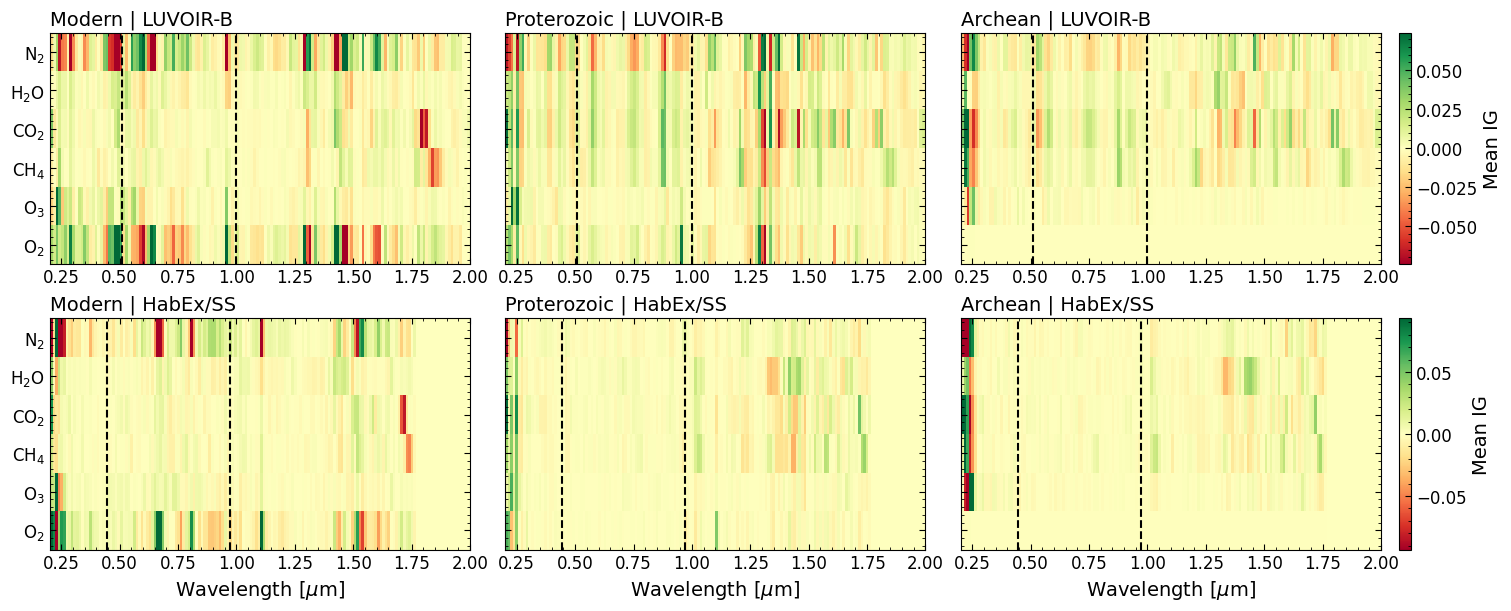

In [15]:
def wavelength_edges(w):
    w = np.asarray(w)
    mids = 0.5 * (w[1:] + w[:-1])
    left = w[0] - 0.5 * (w[1] - w[0])
    right = w[-1] + 0.5 * (w[-1] - w[-2])
    return np.concatenate([[left], mids, [right]])


pretty_heatmap = {
    "O2": r"$\mathrm{O_2}$",
    "O3": r"$\mathrm{O_3}$",
    "CH4": r"$\mathrm{CH_4}$",
    "CO2": r"$\mathrm{CO_2}$",
    "H2O": r"$\mathrm{H_2O}$",
    "N2": r"$\mathrm{N_2}$",
}
gas_labels_heatmap = [pretty_heatmap.get(g, g) for g in gas_order_heatmap]
y_edges = np.arange(len(gas_order_heatmap) + 1) - 0.5

x_edges_B = wavelength_edges(wave_B)
x_edges_SS = wavelength_edges(wave_SS)

vals_L = np.concatenate([ig_heatmap_L[e].ravel() for e in eras_heatmap])
vals_H = np.concatenate([ig_heatmap_H[e].ravel() for e in eras_heatmap])
vmax_L = np.percentile(np.abs(vals_L), 99)
vmax_H = np.percentile(np.abs(vals_H), 99)

cmap_heatmap = "RdYlGn"
zero_color = plt.get_cmap(cmap_heatmap)(0.5)

fig, ax = plt.subplots(
    2, len(eras_heatmap), figsize=(15, 6), sharey=True, layout="constrained"
)
plt.subplots_adjust(wspace=0.12, hspace=0.18)

pcL_ref = None
pcH_ref = None

for j, era in enumerate(eras_heatmap):
    mat_L = ig_heatmap_L[era]
    mat_H = ig_heatmap_H[era]

    pcL = ax[0, j].imshow(
        mat_L,
        aspect="auto",
        extent=[wave_B[0], wave_B[-1], -0.5, len(gas_order_heatmap) - 0.5],
        origin="lower",
        cmap=cmap_heatmap,
        vmin=-vmax_L,
        vmax=vmax_L,
        interpolation="None",
    )
    pcL_ref = pcL

    pcH = ax[1, j].imshow(
        mat_H,
        aspect="auto",
        extent=[wave_SS[0], wave_SS[-1], -0.5, len(gas_order_heatmap) - 0.5],
        origin="lower",
        cmap=cmap_heatmap,
        vmin=-vmax_H,
        vmax=vmax_H,
        interpolation="None",
    )
    pcH_ref = pcH

    ax[1, j].set_facecolor(zero_color)

    ax[0, j].set_title(f"{era.capitalize()} | LUVOIR-B", loc="left")
    ax[1, j].set_title(f"{era.capitalize()} | HabEx/SS", loc="left")

    for row in (0, 1):
        uv = uv_b[-1] if row == 0 else uv_ss[-1]
        vis = vis_b[-1] if row == 0 else vis_ss[-1]
        ax[row, j].axvline(uv, ls="--", c="k")
        ax[row, j].axvline(vis, ls="--", c="k")
        ax[row, j].set_xlim(0.2, 2.0)

for j in range(len(eras_heatmap)):
    ax[1, j].set_xlabel("Wavelength [$\\mu$m]")

ax[0, 0].set_yticks(np.arange(len(gas_labels_heatmap)))
ax[0, 0].set_yticklabels(gas_labels_heatmap)
ax[1, 0].set_yticks(np.arange(len(gas_labels_heatmap)))
ax[1, 0].set_yticklabels(gas_labels_heatmap)

# for row in (0, 1):
#     for j in range(len(eras_heatmap)):
#         ax[row, j].xaxis.set_minor_locator(plt.MultipleLocator(0.1))

cbar_L = fig.colorbar(pcL_ref, ax=ax[0, :], fraction=0.02, pad=0)
cbar_L.set_label("Mean IG")

cbar_H = fig.colorbar(pcH_ref, ax=ax[1, :], fraction=0.02, pad=0)
cbar_H.set_label("Mean IG")

plt.savefig("../images/ig_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()